In [1]:
# Install libraries for 4-bit quantization and LLM inference
!pip install -q -U transformers accelerate bitsandbytes pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 90.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 115.2 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.8 which is incompatible.
ydata-profiling 4.18.1 requ

In [2]:
!pip install openpyxl

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from kaggle_secrets import UserSecretsClient

# Access Hugging Face Token from Kaggle Secrets
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# Configure 4-bit quantization to fit the Tesla T4 GPU (15GB VRAM)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Loading model and tokenizer... please wait.")

tokenizer = AutoTokenizer.from_pretrained(model_id, token=hf_token)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto", 
    token=hf_token,
    low_cpu_mem_usage=True
)

print("Judge Model loaded successfully on GPU!")

Loading model and tokenizer... please wait.


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Judge Model loaded successfully on GPU!


In [4]:
import re
import json
import torch

def extract_confidence_score(text):
    """Extracts numerical confidence value from the text (e.g., '80%')."""
    if not isinstance(text, str): return None
    match = re.search(r'(\d+)\s*%', text)
    return int(match.group(1)) if match else None

def get_llm_judge_rating(context, analysis):
    """Queries the local LLM to score the analysis. Fixed dictionary syntax."""
    
    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>
    You are a Senior Forensic Professor. Evaluate the following IPV analysis on a scale of 1 to 5 for: grounding, coherence, and legal_accuracy.
    
    GRADING MANUAL:
    - GROUNDING: How well signals map to Knowledge Graph concepts.
    - COHERENCE: Logic of the psychological dynamic.
    - LEGAL ACCURACY: Correct application of Italian 'Codice Rosso' articles.

    Respond ONLY with a JSON object.
    Example: {{"grounding": 5, "coherence": 5, "legal_accuracy": 5}}
    <|eot_id|><|start_header_id|>user<|end_header_id|>
    CONTEXT: {context}
    ANALYSIS: {analysis}
    <|eot_id|><|start_header_id|>assistant<|end_header_id|>"""
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=150, 
            temperature=0.1, 
            do_sample=False
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # 1. Attempt to parse JSON by isolating the {} block
    try:
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            json_text = json_match.group().strip()
            data = json.loads(json_text)
            if all(k in data for k in ["grounding", "coherence", "legal_accuracy"]):
                return data
    except Exception as e:
        pass # If JSON fails, proceed to regex fallback
    
    # 2. Regex Fallback: Search for the numbers 1-5 in the text
    try:
        # Find all digits between 1 and 5
        numbers = re.findall(r'\b[1-5]\b', response)
        if len(numbers) >= 3:
            # FIXED SYNTAX: Single braces for dictionary return
            return {
                "grounding": int(numbers[0]), 
                "coherence": int(numbers[1]), 
                "legal_accuracy": int(numbers[2])
            }
    except:
        return None
    
    return None

In [5]:
import pandas as pd
import os
import glob

# Search for the Excel file automatically
excel_files = glob.glob("/kaggle/input/**/*.xlsx", recursive=True)

if not excel_files:
    print("ERROR: No Excel file found. Ensure the dataset is attached.")
else:
    file_path = excel_files[0]
    print(f"Loading: {file_path}")
    df = pd.read_excel(file_path)
    
    # Cleaning data
    df = df.dropna(subset=['Context', 'GraphRAG_Analysis']).reset_index(drop=True)
    df['extracted_confidence'] = df['GraphRAG_Analysis'].apply(extract_confidence_score)

    all_judge_scores = []
    print(f"Evaluating {len(df)} rows. This might take 40-60 minutes...")

    for index, row in df.iterrows():
        if index % 10 == 0:
            print(f"Status: {index}/{len(df)} rows processed...")
        
        scores = get_llm_judge_rating(row['Context'], row['GraphRAG_Analysis'])
        
        if scores:
            all_judge_scores.append(scores)
        else:
            # We append None (NaN) instead of 0 to keep the average accurate
            all_judge_scores.append({"grounding": None, "coherence": None, "legal_accuracy": None})

    # Creating results table
    eval_results_df = pd.DataFrame(all_judge_scores)
    final_df = pd.concat([df, eval_results_df], axis=1)
    
    print("\nEvaluation Complete!")

Loading: /kaggle/input/datasets/federicapicca/ablation-full-comparison1/Ablation_Full_Comparison(1).xlsx


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Evaluating 300 rows. This might take 40-60 minutes...
Status: 0/300 rows processed...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Status: 10/300 rows processed...


...

Status: 280/300 rows processed...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Status: 290/300 rows processed...


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.



Evaluation Complete!


In [6]:
# Calculate means ignoring NaN values
avg_grounding = eval_results_df['grounding'].mean()
avg_coherence = eval_results_df['coherence'].mean()
avg_legal = eval_results_df['legal_accuracy'].mean()
avg_confidence = df['extracted_confidence'].mean()

# Total Project Score
total_avg_score = (avg_grounding + avg_coherence + avg_legal) / 3

print("\n" + "="*45)
print("  FORENSIC NLP PROJECT: VALIDATION SUMMARY")
print("="*45)
print(f"1. Factual Grounding:   {avg_grounding:.2f} / 5.00")
print(f"2. Clinical Coherence:  {avg_coherence:.2f} / 5.00")
print(f"3. Legal Accuracy:      {avg_legal:.2f} / 5.00")
print("-" * 45)
print(f"   TOTAL AVERAGE SCORE: {total_avg_score:.2f} / 5.00")
print("-" * 45)
print(f"   Model Mean Confidence: {avg_confidence:.2f} %")
print("="*45)

final_df.to_csv("Evaluation_Results_Corrected.csv", index=False)


  FORENSIC NLP PROJECT: VALIDATION SUMMARY
1. Factual Grounding:   1.09 / 5.00
2. Clinical Coherence:  5.00 / 5.00
3. Legal Accuracy:      5.00 / 5.00
---------------------------------------------
   TOTAL AVERAGE SCORE: 3.70 / 5.00
---------------------------------------------
   Model Mean Confidence: 82.70 %



        PERFORMANCE ANALYSIS BY STRATEGY
                                 grounding  coherence  legal_accuracy  \
Strategy                                                                
Strategy 1: Single-shot               1.14        5.0             5.0   
Strategy 2: Single-LLM Roleplay       1.04        5.0             5.0   
Strategy 3: Dual-LLM Roleplay         1.09        5.0             5.0   

                                 total_judge_score  extracted_confidence  
Strategy                                                                  
Strategy 1: Single-shot                       3.71                 83.81  
Strategy 2: Single-LLM Roleplay               3.68                 82.00  
Strategy 3: Dual-LLM Roleplay                 3.70                 80.91  


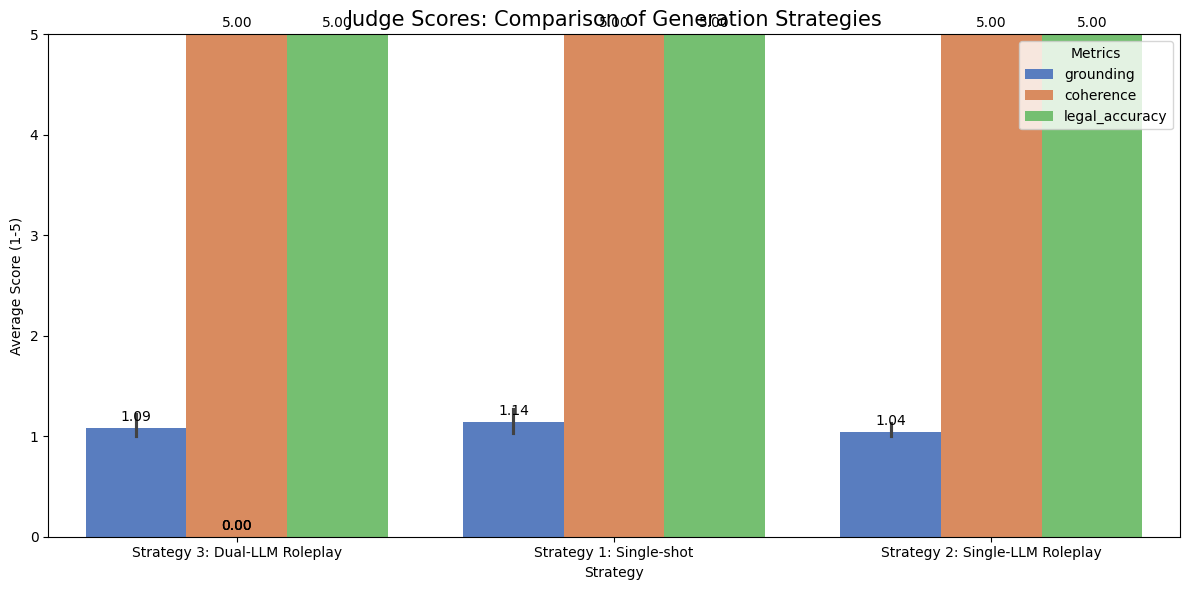

In [7]:
# 1. Create a "Total Judge Score" for easy comparison
final_df['total_judge_score'] = (final_df['grounding'] + final_df['coherence'] + final_df['legal_accuracy']) / 3

# 2. Group by Strategy and calculate means
strategy_comparison = final_df.groupby('Strategy').agg({
    'grounding': 'mean',
    'coherence': 'mean',
    'legal_accuracy': 'mean',
    'total_judge_score': 'mean',
    'extracted_confidence': 'mean'
}).round(2)

print("\n" + "="*50)
print("        PERFORMANCE ANALYSIS BY STRATEGY")
print("="*50)
print(strategy_comparison)
print("="*50)

# 3. Visualization: Compare Strategies side-by-side
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Prepare data for plotting (melt the dataframe)
plot_df = final_df.melt(id_vars=['Strategy'], 
                        value_vars=['grounding', 'coherence', 'legal_accuracy'],
                        var_name='Metric', value_name='Score')

ax = sns.barplot(x='Strategy', y='Score', hue='Metric', data=plot_df, palette='muted')
plt.title("Judge Scores: Comparison of Generation Strategies", fontsize=15)
plt.ylim(0, 5)
plt.ylabel("Average Score (1-5)")
plt.legend(title='Metrics', loc='upper right')

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

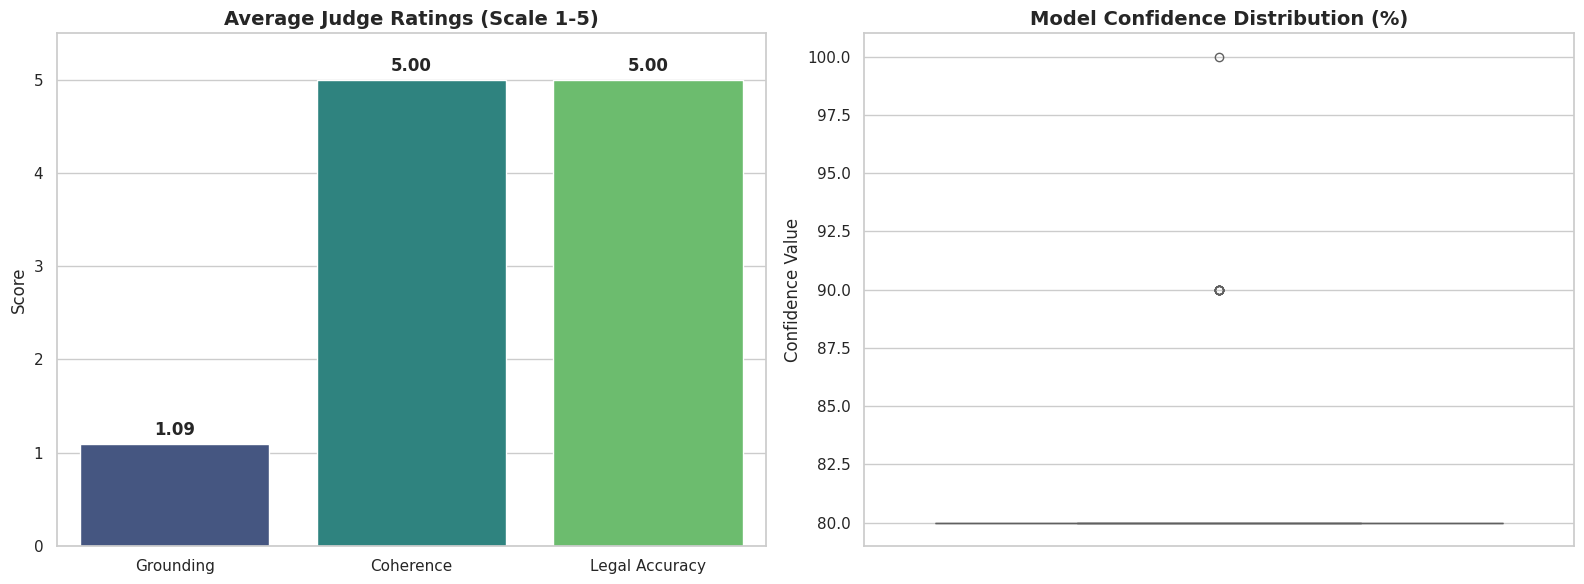

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Re-calculate metrics inside the cell to avoid NameError
if 'eval_results_df' in locals() and not eval_results_df.empty:
    
    # Calculate averages from the results table
    v_grounding = eval_results_df['grounding'].mean()
    v_coherence = eval_results_df['coherence'].mean()
    v_legal = eval_results_df['legal_accuracy'].mean()
    
    # Values for the plot
    metrics_labels = ['Grounding', 'Coherence', 'Legal Accuracy']
    metrics_values = [v_grounding, v_coherence, v_legal]

    # Set professional style
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- PLOT 1: Judge Ratings ---
    sns.barplot(x=metrics_labels, y=metrics_values, hue=metrics_labels, ax=ax1, palette="viridis", legend=False)
    ax1.set_ylim(0, 5.5)
    ax1.set_title("Average Judge Ratings (Scale 1-5)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Score")

    # Add numbers on top of bars
    for i, v in enumerate(metrics_values):
        if pd.notnull(v):
            ax1.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)

    # --- PLOT 2: Confidence Distribution ---
    if 'extracted_confidence' in df.columns:
        sns.boxplot(y=df['extracted_confidence'], ax=ax2, color="#5dade2")
        ax2.set_title("Model Confidence Distribution (%)", fontsize=14, fontweight='bold')
        ax2.set_ylabel("Confidence Value")
    
    plt.tight_layout()
    plt.show()

else:
    print("ERROR: 'eval_results_df' not found. Please run Cell 4 first!")

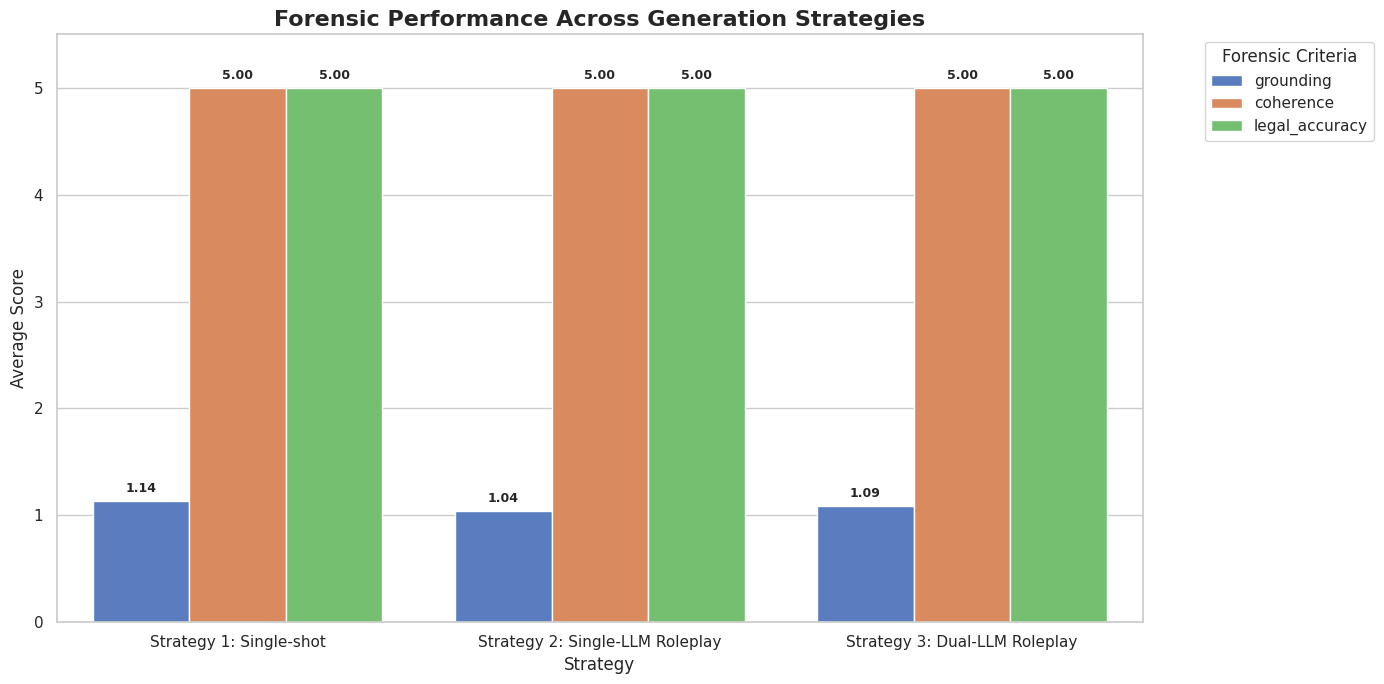

In [9]:
plt.figure(figsize=(14, 7))

# We prepare the data ensuring no values are missing
plot_data = final_df.groupby('Strategy')[['grounding', 'coherence', 'legal_accuracy']].mean().reset_index()
plot_melted = plot_data.melt(id_vars='Strategy', var_name='Metric', value_name='Score')

ax = sns.barplot(data=plot_melted, x='Strategy', y='Score', hue='Metric', palette="muted")

plt.title("Forensic Performance Across Generation Strategies", fontsize=16, fontweight='bold')
plt.ylim(0, 5.5) # Extra space for labels
plt.ylabel("Average Score")
plt.legend(title="Forensic Criteria", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add values on the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()